# EDA 9.2: Overstock Analysis

This notebook analyzes overstock risk, identifies product, category, and segment groups with high inventory but slow sales, and prepares leakage-safe overstock features for Revenue forecasting. Inventory appears monthly in this dataset, so sales and inventory are aligned at monthly level first, then lagged monthly inventory signals are merged into daily Revenue rows.

## 1. Setup and File Discovery

Locate `inventory.csv`, `products.csv`, and optional sales-order files anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['inventory.csv', 'products.csv', 'sales.csv', 'order_items.csv', 'orders.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def safe_label(value):
    label = re.sub(r'[^a-z0-9]+', '_', str(value).strip().lower()).strip('_')
    return label or 'unknown'

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in ['inventory.csv', 'products.csv'], 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in ['inventory.csv', 'products.csv']:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,inventory.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\in...
1,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
2,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
3,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...


## 2. Load Inventory, Products, and Optional Sales/Order Files

Load all available CSVs safely with pandas and display the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

raw = {name: safe_read_csv(path, name) for name, path in selected_paths.items()}
inventory_raw = raw.get('inventory.csv')
products_raw = raw.get('products.csv')
sales_raw = raw.get('sales.csv')
order_items_raw = raw.get('order_items.csv')
orders_raw = raw.get('orders.csv')

schema_rows = []
for name, df in raw.items():
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded inventory.csv: 60,247 rows x 17 columns from D:\Code\Datathon 2026\datathon-2026-round-1\inventory.csv
Loaded products.csv: 2,412 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\products.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


Loaded order_items.csv: 714,669 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\order_items.csv


Loaded orders.csv: 646,945 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\orders.csv


,file,rows,columns,column_names
0,inventory.csv,60247,17,"snapshot_date, product_id, stock_on_hand, unit..."
1,products.csv,2412,8,"product_id, product_name, category, segment, s..."
2,sales.csv,3833,3,"Date, Revenue, COGS"
3,order_items.csv,714669,7,"order_id, product_id, quantity, unit_price, di..."
4,orders.csv,646945,8,"order_id, order_date, customer_id, zip, order_..."


## 3. Identify Product, Inventory, Sales Quantity, Category, Segment, and Date Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def infer_revenue_col(df):
    if df is None:
        return None
    direct = find_col(
        df,
        ['revenue', 'total_revenue', 'sales_amount', 'sales', 'net_sales', 'amount'],
        include_any=['revenue', 'salesamount', 'totalsales', 'netsales'],
        exclude_any=['cost', 'cogs', 'margin', 'profit', 'tax'],
        prefer_numeric=True,
    )
    if direct is not None:
        return direct
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or to_num(df[c]).notna().mean() > 0.8]
    candidates = []
    for c in numeric_cols:
        key = normalize_name(c)
        if any(x in key for x in ['cost', 'cogs', 'margin', 'profit', 'tax', 'id']):
            continue
        vals = to_num(df[c])
        candidates.append(((vals > 0).mean(), vals.abs().sum(skipna=True), c))
    if candidates:
        candidates.sort(key=lambda x: (-x[0], -x[1], str(x[2])))
        warnings.warn(f'Revenue column was not explicit; using likely numeric revenue column: {candidates[0][2]}')
        return candidates[0][2]
    return None

cols = {}
if inventory_raw is not None:
    cols['inv_product_id'] = find_col(inventory_raw, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['inv_date'] = find_col(inventory_raw, ['snapshot_date', 'inventory_date', 'date', 'month_end_date'], include_any=['snapshotdate', 'inventorydate', 'date'])
    cols['inv_year'] = find_col(inventory_raw, ['year'], include_any=['year'], prefer_numeric=True)
    cols['inv_month'] = find_col(inventory_raw, ['month'], include_any=['month'], prefer_numeric=True)
    cols['stock_on_hand'] = find_col(inventory_raw, ['stock_on_hand', 'stock_qty', 'inventory_qty', 'available_quantity', 'available_inventory', 'on_hand_qty'], include_any=['stockonhand', 'stockqty', 'inventoryqty', 'availablequantity', 'availableinventory', 'onhandqty'], prefer_numeric=True)
    cols['inv_units_sold'] = find_col(inventory_raw, ['units_sold', 'quantity_sold', 'qty_sold', 'sales_units'], include_any=['unitssold', 'quantitysold', 'qtysold', 'salesunits'], prefer_numeric=True)
    cols['days_of_supply'] = find_col(inventory_raw, ['days_of_supply', 'inventory_days_of_supply'], include_any=['daysofsupply'], prefer_numeric=True)
    cols['sell_through_rate'] = find_col(inventory_raw, ['sell_through_rate', 'sellthrough_rate', 'turn_rate'], include_any=['sellthroughrate', 'turnrate'], prefer_numeric=True)
    cols['inv_category'] = find_col(inventory_raw, ['category', 'product_category'], include_any=['category'])
    cols['inv_segment'] = find_col(inventory_raw, ['segment', 'product_segment'], include_any=['segment'])
if products_raw is not None:
    cols['prod_product_id'] = find_col(products_raw, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['prod_category'] = find_col(products_raw, ['category', 'product_category'], include_any=['category'])
    cols['prod_segment'] = find_col(products_raw, ['segment', 'product_segment'], include_any=['segment'])
if order_items_raw is not None:
    cols['oi_order_id'] = find_col(order_items_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['oi_product_id'] = find_col(order_items_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['oi_quantity'] = find_col(order_items_raw, ['quantity', 'qty', 'units_sold'], include_any=['quantity', 'qty', 'unitssold'], prefer_numeric=True)
    cols['oi_unit_price'] = find_col(order_items_raw, ['unit_price', 'selling_price', 'price'], include_any=['unitprice', 'sellingprice', 'price'], exclude_any=['discount', 'cost'], prefer_numeric=True)
    cols['oi_discount'] = find_col(order_items_raw, ['discount_amount', 'discount_value', 'discount'], include_any=['discountamount', 'discountvalue', 'discount'], exclude_any=['id'], prefer_numeric=True)
    cols['oi_date'] = find_col(order_items_raw, ['order_date', 'date', 'item_date'], include_any=['date'])
if orders_raw is not None:
    cols['orders_order_id'] = find_col(orders_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['orders_date'] = find_col(orders_raw, ['order_date', 'date'], include_any=['orderdate', 'date'])
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date'], include_any=['date'])
    cols['sales_revenue'] = infer_revenue_col(sales_raw)
    cols['sales_product_id'] = find_col(sales_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['sales_quantity'] = find_col(sales_raw, ['units_sold', 'quantity', 'qty', 'sales_units'], include_any=['unitssold', 'quantity', 'qty', 'salesunits'], prefer_numeric=True)

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,inv_product_id,product_id
1,inv_date,snapshot_date
2,inv_year,year
3,inv_month,month
4,stock_on_hand,stock_on_hand
5,inv_units_sold,units_sold
6,days_of_supply,days_of_supply
7,sell_through_rate,sell_through_rate
8,inv_category,category
9,inv_segment,segment


## 4. Inventory Data Quality Checks

Inspect inventory date coverage, granularity, duplicate product-period rows, missing values, and invalid stock values.

In [4]:
inventory = pd.DataFrame()
inventory_warnings = []
inventory_granularity = 'unknown'

if inventory_raw is None or inventory_raw.empty:
    inventory_warnings.append('inventory.csv is missing or empty.')
elif cols.get('inv_product_id') is None:
    inventory_warnings.append('Inventory product ID column could not be identified.')
else:
    inventory = inventory_raw.copy()
    inventory['product_id_std'] = inventory[cols['inv_product_id']].astype('string').str.strip()
    if cols.get('inv_date'):
        inventory['inventory_date'] = pd.to_datetime(inventory[cols['inv_date']], errors='coerce').dt.floor('D')
    elif cols.get('inv_year') and cols.get('inv_month'):
        inventory['inventory_date'] = pd.to_datetime(
            inventory[cols['inv_year']].astype('Int64').astype(str) + '-' + inventory[cols['inv_month']].astype('Int64').astype(str).str.zfill(2) + '-01',
            errors='coerce'
        ) + pd.offsets.MonthEnd(0)
    else:
        inventory['inventory_date'] = pd.NaT
        inventory_warnings.append('Inventory date/month could not be identified.')

    if cols.get('stock_on_hand'):
        inventory['stock_on_hand_std'] = to_num(inventory[cols['stock_on_hand']])
    if cols.get('inv_units_sold'):
        inventory['inventory_units_sold_std'] = to_num(inventory[cols['inv_units_sold']])
    if cols.get('days_of_supply'):
        inventory['days_of_supply_std'] = to_num(inventory[cols['days_of_supply']])
    if cols.get('sell_through_rate'):
        st = to_num(inventory[cols['sell_through_rate']])
        inventory['sell_through_rate_std'] = np.where(st.abs() > 1.5, st / 100.0, st)

    if inventory['inventory_date'].notna().sum() >= 2:
        diffs = inventory[['inventory_date']].dropna().sort_values('inventory_date')['inventory_date'].diff().dropna().dt.days
        if not diffs.empty:
            med = diffs.median()
            inventory_granularity = 'monthly' if med >= 25 else ('daily' if med <= 2 else 'irregular')
        else:
            inventory_granularity = 'single_period'
    duplicate_rows = int(inventory.duplicated(['product_id_std', 'inventory_date']).sum()) if 'inventory_date' in inventory else np.nan
    report = pd.DataFrame([
        {'metric': 'inventory_date_range_start', 'value': inventory['inventory_date'].min()},
        {'metric': 'inventory_date_range_end', 'value': inventory['inventory_date'].max()},
        {'metric': 'inventory_rows', 'value': len(inventory)},
        {'metric': 'unique_products', 'value': inventory['product_id_std'].nunique(dropna=True)},
        {'metric': 'missing_product_ids', 'value': int(inventory['product_id_std'].isna().sum())},
        {'metric': 'missing_inventory_dates', 'value': int(inventory['inventory_date'].isna().sum())},
        {'metric': 'missing_stock_on_hand', 'value': int(inventory['stock_on_hand_std'].isna().sum()) if 'stock_on_hand_std' in inventory else np.nan},
        {'metric': 'duplicate_product_date_rows', 'value': duplicate_rows},
        {'metric': 'zero_stock_values', 'value': int((inventory['stock_on_hand_std'].fillna(0) == 0).sum()) if 'stock_on_hand_std' in inventory else np.nan},
        {'metric': 'negative_stock_values', 'value': int((inventory['stock_on_hand_std'].fillna(0) < 0).sum()) if 'stock_on_hand_std' in inventory else np.nan},
        {'metric': 'detected_granularity', 'value': inventory_granularity},
    ])
    display(report)
    display(inventory.head())
    numeric_cols = [c for c in ['stock_on_hand_std', 'inventory_units_sold_std', 'days_of_supply_std', 'sell_through_rate_std'] if c in inventory.columns]
    if numeric_cols:
        display(inventory[numeric_cols].describe().T)

if inventory_warnings:
    print('Inventory warnings:')
    for w in inventory_warnings:
        print('-', w)

,metric,value
0,inventory_date_range_start,2012-07-31 00:00:00
1,inventory_date_range_end,2022-12-31 00:00:00
2,inventory_rows,60247
3,unique_products,1624
4,missing_product_ids,0
5,missing_inventory_dates,0
6,missing_stock_on_hand,0
7,duplicate_product_date_rows,0
8,zero_stock_values,0
9,negative_stock_values,0


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,product_id_std,inventory_date,stock_on_hand_std,inventory_units_sold_std,days_of_supply_std,sell_through_rate_std
0,2022-10-31,1,3,1,1,2,90.0000,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10,1,2022-10-31,3,1,90.0000,0.2500
1,2022-11-30,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11,1,2022-11-30,3,1,90.0000,0.2500
2,2022-12-31,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12,1,2022-12-31,3,1,90.0000,0.2500
3,2016-04-30,3,35,13,11,2,95.5000,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4,3,2016-04-30,35,11,95.5000,0.2391
4,2016-05-31,3,36,11,10,1,108.0000,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5,3,2016-05-31,36,10,108.0000,0.2174


,count,mean,std,min,25%,50%,75%,max
stock_on_hand_std,"60,247.0000",189.2985,316.9761,3.0000,15.0000,62.0000,210.0000,"2,673.0000"
inventory_units_sold_std,"60,247.0000",15.4178,28.4044,1.0000,2.0000,6.0000,16.0000,670.0000
days_of_supply_std,"60,247.0000",912.6776,"2,587.6241",5.2000,96.0000,240.0000,683.1000,"68,100.0000"
sell_through_rate_std,"60,247.0000",0.1523,0.1393,0.0004,0.0421,0.1111,0.2381,0.8531


## 5. Join Inventory with Products

Join inventory to products by product ID, bring in category and segment when available, and report join quality.

In [5]:
inventory_joined = pd.DataFrame()
join_quality = pd.DataFrame()

if inventory.empty:
    print('Inventory data is unavailable; product join cannot be computed.')
else:
    inventory_joined = inventory.copy()
    if products_raw is not None and cols.get('prod_product_id'):
        prod = products_raw.copy()
        prod['product_id_std'] = prod[cols['prod_product_id']].astype('string').str.strip()
        prod_keep = ['product_id_std']
        for c in [cols.get('prod_category'), cols.get('prod_segment')]:
            if c and c not in prod_keep:
                prod_keep.append(c)
        prod = prod[prod_keep].drop_duplicates('product_id_std')
        product_id_set = set(prod['product_id_std'].dropna())
        matched = int(inventory_joined['product_id_std'].isin(product_id_set).sum())
        unmatched = int(len(inventory_joined) - matched)
        products_without_inventory = int(len(prod.loc[~prod['product_id_std'].isin(set(inventory_joined['product_id_std'].dropna()))]))
        inventory_joined = inventory_joined.merge(prod, on='product_id_std', how='left', suffixes=('', '_prod'))
        join_quality = pd.DataFrame([
            {'metric': 'inventory_rows_matched_to_products', 'value': matched},
            {'metric': 'inventory_rows_unmatched_to_products', 'value': unmatched},
            {'metric': 'products_without_inventory_records', 'value': products_without_inventory},
        ])
        display(join_quality)
        if unmatched > 0:
            print('Sample unmatched product IDs:')
            display(inventory_joined.loc[~inventory_joined['product_id_std'].isin(product_id_set), ['product_id_std']].drop_duplicates().head(20))
    else:
        print('Products file or product key is unavailable; join quality cannot be fully evaluated.')
        inventory_joined = inventory.copy()

    inv_cat_col = cols.get('inv_category') if cols.get('inv_category') in inventory_joined.columns else None
    prod_cat_col = cols.get('prod_category') if cols.get('prod_category') in inventory_joined.columns else None
    inv_seg_col = cols.get('inv_segment') if cols.get('inv_segment') in inventory_joined.columns else None
    prod_seg_col = cols.get('prod_segment') if cols.get('prod_segment') in inventory_joined.columns else None
    if inv_cat_col:
        inventory_joined['category_final'] = inventory_joined[inv_cat_col].astype('string').fillna('Unknown')
    elif prod_cat_col:
        inventory_joined['category_final'] = inventory_joined[prod_cat_col].astype('string').fillna('Unknown')
    else:
        inventory_joined['category_final'] = 'Unknown'
        inventory_warnings.append('Product category could not be identified; category-level analysis will be limited.')
    if inv_seg_col:
        inventory_joined['segment_final'] = inventory_joined[inv_seg_col].astype('string').fillna('Unknown')
    elif prod_seg_col:
        inventory_joined['segment_final'] = inventory_joined[prod_seg_col].astype('string').fillna('Unknown')
    else:
        inventory_joined['segment_final'] = pd.NA
        inventory_warnings.append('Product segment could not be identified; segment-level analysis may be skipped.')

,metric,value
0,inventory_rows_matched_to_products,60247
1,inventory_rows_unmatched_to_products,0
2,products_without_inventory_records,788


## 6. Build Sales Quantity Dataset

Prefer `inventory.units_sold` when available because it is already aligned to inventory periods. Otherwise rebuild product-month sales from `order_items` plus `orders`, or use product-level sales if present in `sales.csv`.

In [6]:
sales_qty_monthly = pd.DataFrame()
sales_qty_warnings = []
sales_qty_source = 'unavailable'

if not inventory_joined.empty and 'inventory_units_sold_std' in inventory_joined.columns and inventory_joined['inventory_units_sold_std'].notna().any():
    temp = inventory_joined[['product_id_std', 'inventory_date', 'inventory_units_sold_std']].dropna(subset=['inventory_date']).copy()
    temp['year_month'] = temp['inventory_date'].dt.to_period('M').astype('string')
    sales_qty_monthly = temp.groupby(['product_id_std', 'year_month'], as_index=False)['inventory_units_sold_std'].sum(min_count=1).rename(columns={'inventory_units_sold_std': 'units_sold'})
    sales_qty_source = 'inventory.units_sold'
elif order_items_raw is not None and orders_raw is not None and cols.get('oi_product_id') and cols.get('oi_quantity'):
    oi = order_items_raw.copy()
    oi['product_id_std'] = oi[cols['oi_product_id']].astype('string').str.strip()
    oi['units_sold'] = to_num(oi[cols['oi_quantity']])
    if cols.get('oi_date'):
        oi['sales_date'] = pd.to_datetime(oi[cols['oi_date']], errors='coerce').dt.floor('D')
    elif cols.get('oi_order_id') and cols.get('orders_order_id') and cols.get('orders_date'):
        od = orders_raw[[cols['orders_order_id'], cols['orders_date']]].drop_duplicates(cols['orders_order_id']).copy()
        od['sales_date'] = pd.to_datetime(od[cols['orders_date']], errors='coerce').dt.floor('D')
        oi = oi.merge(od[[cols['orders_order_id'], 'sales_date']], left_on=cols['oi_order_id'], right_on=cols['orders_order_id'], how='left')
    else:
        oi['sales_date'] = pd.NaT
    if cols.get('oi_unit_price'):
        oi['unit_price_std'] = to_num(oi[cols['oi_unit_price']])
        oi['discount_std'] = to_num(oi[cols['oi_discount']]) if cols.get('oi_discount') else 0
        oi['revenue_proxy'] = oi['unit_price_std'] * oi['units_sold']
    oi = oi.dropna(subset=['sales_date'])
    oi['year_month'] = oi['sales_date'].dt.to_period('M').astype('string')
    agg = {'units_sold': 'sum'}
    if 'revenue_proxy' in oi.columns:
        agg['revenue_proxy'] = 'sum'
    sales_qty_monthly = oi.groupby(['product_id_std', 'year_month'], as_index=False).agg(agg)
    sales_qty_source = 'order_items + orders'
elif sales_raw is not None and cols.get('sales_product_id') and cols.get('sales_quantity') and cols.get('sales_date'):
    sa = sales_raw.copy()
    sa['product_id_std'] = sa[cols['sales_product_id']].astype('string').str.strip()
    sa['sales_date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['units_sold'] = to_num(sa[cols['sales_quantity']])
    sa['year_month'] = sa['sales_date'].dt.to_period('M').astype('string')
    sales_qty_monthly = sa.groupby(['product_id_std', 'year_month'], as_index=False)['units_sold'].sum(min_count=1)
    sales_qty_source = 'sales product-level quantity'
else:
    sales_qty_warnings.append('Sales quantity could not be built from inventory, order_items + orders, or product-level sales.')

print('Sales quantity source:', sales_qty_source)
if not sales_qty_monthly.empty:
    ym_ts = pd.PeriodIndex(sales_qty_monthly['year_month'], freq='M').to_timestamp()
    report = pd.DataFrame([
        {'metric': 'sales_qty_start', 'value': ym_ts.min()},
        {'metric': 'sales_qty_end', 'value': ym_ts.max()},
        {'metric': 'product_month_records', 'value': len(sales_qty_monthly)},
        {'metric': 'missing_units_sold', 'value': int(sales_qty_monthly['units_sold'].isna().sum())},
        {'metric': 'zero_units_sold', 'value': int((sales_qty_monthly['units_sold'].fillna(0) == 0).sum())},
        {'metric': 'negative_units_sold', 'value': int((sales_qty_monthly['units_sold'].fillna(0) < 0).sum())},
    ])
    display(report)
    display(sales_qty_monthly.head())
else:
    print('Sell-through and days-of-supply analysis will be limited because product-month sales quantity is unavailable.')

if sales_qty_warnings:
    print('Sales quantity warnings:')
    for w in sales_qty_warnings:
        print('-', w)

Sales quantity source: inventory.units_sold


,metric,value
0,sales_qty_start,2012-07-01 00:00:00
1,sales_qty_end,2022-12-01 00:00:00
2,product_month_records,60247
3,missing_units_sold,0
4,zero_units_sold,0
5,negative_units_sold,0


,product_id_std,year_month,units_sold
0,1,2022-10,1
1,1,2022-11,1
2,1,2022-12,1
3,10,2012-10,1
4,10,2013-01,2


## 7. Align Inventory and Sales at Monthly/Daily Granularity

Inventory and sales are aligned at product-month level because inventory is monthly in this dataset. Products with inventory but no sales in a month are assigned `units_sold = 0` where appropriate.

In [7]:
aligned_pm = pd.DataFrame()
revenue_daily = pd.DataFrame()

if inventory_joined.empty:
    print('Inventory data is unavailable; aligned product-month data cannot be built.')
else:
    inv = inventory_joined.dropna(subset=['inventory_date']).copy()
    inv['year_month'] = inv['inventory_date'].dt.to_period('M').astype('string')
    inv = inv.sort_values(['product_id_std', 'inventory_date'])
    pm_rows = []
    for (pid, ym), g in inv.groupby(['product_id_std', 'year_month']):
        last_row = g.sort_values('inventory_date').iloc[-1]
        pm_rows.append({
            'product_id_std': pid,
            'year_month': ym,
            'month_start': pd.Period(ym).to_timestamp(),
            'stock_on_hand': last_row['stock_on_hand_std'] if 'stock_on_hand_std' in g else np.nan,
            'category_final': last_row['category_final'] if 'category_final' in g else 'Unknown',
            'segment_final': last_row['segment_final'] if 'segment_final' in g else pd.NA,
            'days_of_supply_raw': g['days_of_supply_std'].mean() if 'days_of_supply_std' in g else np.nan,
            'sell_through_rate_raw': g['sell_through_rate_std'].mean() if 'sell_through_rate_std' in g else np.nan,
        })
    aligned_pm = pd.DataFrame(pm_rows)
    if not sales_qty_monthly.empty:
        aligned_pm = aligned_pm.merge(sales_qty_monthly, on=['product_id_std', 'year_month'], how='left')
        aligned_pm['units_sold'] = aligned_pm['units_sold'].fillna(0)
        if 'revenue_proxy' in aligned_pm.columns:
            aligned_pm['revenue_proxy'] = aligned_pm['revenue_proxy'].fillna(0)
    else:
        aligned_pm['units_sold'] = np.nan
    display(aligned_pm.head(20))

if sales_raw is not None and cols.get('sales_date') and cols.get('sales_revenue'):
    sa = sales_raw.copy()
    sa['date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['revenue'] = to_num(sa[cols['sales_revenue']])
    revenue_daily = sa.dropna(subset=['date']).groupby('date', as_index=False)['revenue'].sum(min_count=1).sort_values('date')
    revenue_daily['year_month'] = revenue_daily['date'].dt.to_period('M').astype('string')

,product_id_std,year_month,month_start,stock_on_hand,category_final,segment_final,days_of_supply_raw,sell_through_rate_raw,units_sold
0,1,2022-10,2022-10-01,3,Casual,All-weather,90.0000,0.2500,1
1,1,2022-11,2022-11-01,3,Casual,All-weather,90.0000,0.2500,1
2,1,2022-12,2022-12-01,3,Casual,All-weather,90.0000,0.2500,1
3,10,2012-10,2012-10-01,3,Casual,All-weather,90.0000,0.2500,1
4,10,2013-01,2013-01-01,3,Casual,All-weather,45.0000,0.4000,2
5,10,2013-02,2013-02-01,4,Casual,All-weather,20.0000,0.6000,6
6,10,2013-03,2013-03-01,4,Casual,All-weather,24.0000,0.5556,5
7,10,2013-04,2013-04-01,4,Casual,All-weather,40.0000,0.4286,3
8,10,2013-05,2013-05-01,4,Casual,All-weather,60.0000,0.3333,2
9,10,2013-06,2013-06-01,4,Casual,All-weather,120.0000,0.2000,1


## 8. Define Overstock and Sell-Through Metrics

Create interpretable overstock metrics. Overstock is defined from high stock combined with slow sales or weak sell-through within category context.

In [8]:
overstock_definition = ''
if aligned_pm.empty:
    print('Aligned product-month data is unavailable; overstock metrics cannot be defined.')
else:
    pm = aligned_pm.copy()
    pm['sell_through_rate'] = np.where((pm['stock_on_hand'] > 0) & pm['units_sold'].notna(), pm['units_sold'] / pm['stock_on_hand'], np.nan)
    pm['inventory_to_sales_ratio'] = np.where(pm['units_sold'] > 0, pm['stock_on_hand'] / pm['units_sold'], np.nan)
    month_days = pd.PeriodIndex(pm['year_month'], freq='M').days_in_month
    pm['avg_daily_units_sold'] = np.where(pm['units_sold'].notna(), pm['units_sold'] / month_days, np.nan)
    pm['days_of_supply'] = np.where(pm['avg_daily_units_sold'] > 0, pm['stock_on_hand'] / pm['avg_daily_units_sold'], np.nan)
    if 'days_of_supply_raw' in pm.columns and pm['days_of_supply_raw'].notna().any():
        pm['days_of_supply'] = pm['days_of_supply'].fillna(pm['days_of_supply_raw'])
    if 'sell_through_rate_raw' in pm.columns and pm['sell_through_rate_raw'].notna().any():
        pm['sell_through_rate'] = pm['sell_through_rate'].fillna(pm['sell_through_rate_raw'])

    grp = pm.groupby('category_final')
    pm['cat_stock_q75'] = grp['stock_on_hand'].transform(lambda s: s.quantile(0.75))
    pm['cat_stock_median'] = grp['stock_on_hand'].transform('median')
    if pm['units_sold'].notna().any():
        pm['cat_sales_median'] = grp['units_sold'].transform('median')
        pm['cat_sales_q25'] = grp['units_sold'].transform(lambda s: s.quantile(0.25))
    else:
        pm['cat_sales_median'] = np.nan
        pm['cat_sales_q25'] = np.nan
    if pm['sell_through_rate'].notna().any():
        pm['cat_sellthrough_q25'] = grp['sell_through_rate'].transform(lambda s: s.quantile(0.25))
    else:
        pm['cat_sellthrough_q25'] = np.nan

    high_stock = pm['stock_on_hand'] >= pm['cat_stock_q75']
    low_sales = pm['units_sold'].fillna(0) <= pm['cat_sales_median'].fillna(0)
    weak_sellthrough = pm['sell_through_rate'].fillna(np.inf) <= pm['cat_sellthrough_q25'].fillna(-np.inf)
    pm['overstock_flag'] = ((high_stock & low_sales) | (high_stock & weak_sellthrough)).fillna(False)
    overstock_definition = 'Overstock flag = stock_on_hand >= category 75th percentile and either units_sold <= category median or sell_through_rate <= category 25th percentile.'

    aligned_pm = pm
    print('Overstock definition used:')
    print(overstock_definition)
    display(aligned_pm[['product_id_std', 'year_month', 'category_final', 'stock_on_hand', 'units_sold', 'sell_through_rate', 'inventory_to_sales_ratio', 'days_of_supply', 'overstock_flag']].head(20))

Overstock definition used:
Overstock flag = stock_on_hand >= category 75th percentile and either units_sold <= category median or sell_through_rate <= category 25th percentile.


,product_id_std,year_month,category_final,stock_on_hand,units_sold,sell_through_rate,inventory_to_sales_ratio,days_of_supply,overstock_flag
0,1,2022-10,Casual,3,1,0.3333,3.0000,93.0000,False
1,1,2022-11,Casual,3,1,0.3333,3.0000,90.0000,False
2,1,2022-12,Casual,3,1,0.3333,3.0000,93.0000,False
3,10,2012-10,Casual,3,1,0.3333,3.0000,93.0000,False
4,10,2013-01,Casual,3,2,0.6667,1.5000,46.5000,False
5,10,2013-02,Casual,4,6,1.5000,0.6667,18.6667,False
6,10,2013-03,Casual,4,5,1.2500,0.8000,24.8000,False
7,10,2013-04,Casual,4,3,0.7500,1.3333,40.0000,False
8,10,2013-05,Casual,4,2,0.5000,2.0000,62.0000,False
9,10,2013-06,Casual,4,1,0.2500,4.0000,120.0000,False


## 9. Overstock Count by Category

Aggregate overstock metrics by category and identify categories with high overstock concentration.

,category_final,number_of_products,total_stock_on_hand,total_units_sold,average_sell_through_rate,median_sell_through_rate,overstock_product_count,overstock_rate,average_days_of_supply,small_product_count_flag
3,Streetwear,890,5759494,511467,0.2405,0.1370,4125,0.1330,900.3118,False
2,Outdoor,502,4749891,337510,0.1955,0.1000,2845,0.1352,"1,084.9624",False
1,GenZ,113,584757,48695,0.2554,0.1429,728,0.1558,729.2167,True
0,Casual,119,310522,31202,0.2535,0.1538,533,0.1522,465.4575,False


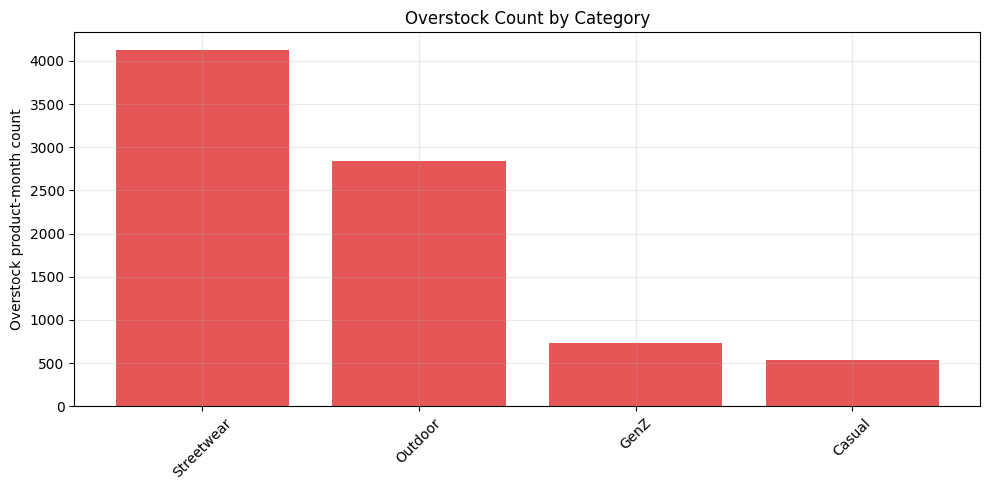

In [9]:
category_overstock = pd.DataFrame()
if aligned_pm.empty or 'category_final' not in aligned_pm.columns:
    print('Category data is unavailable; category overstock analysis cannot be computed.')
else:
    pm = aligned_pm.copy()
    category_overstock = pm.groupby('category_final').agg(
        number_of_products=('product_id_std', 'nunique'),
        total_stock_on_hand=('stock_on_hand', 'sum'),
        total_units_sold=('units_sold', 'sum'),
        average_sell_through_rate=('sell_through_rate', 'mean'),
        median_sell_through_rate=('sell_through_rate', 'median'),
        overstock_product_count=('overstock_flag', lambda s: int(s.fillna(False).sum())),
        overstock_rate=('overstock_flag', lambda s: s.fillna(False).mean()),
        average_days_of_supply=('days_of_supply', 'mean'),
    ).reset_index()
    category_overstock['small_product_count_flag'] = category_overstock['number_of_products'] < max(5, category_overstock['number_of_products'].quantile(0.1))
    category_overstock = category_overstock.sort_values(['overstock_product_count', 'overstock_rate'], ascending=False)
    display(category_overstock)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(category_overstock['category_final'].astype(str), category_overstock['overstock_product_count'], color='#E45756')
    ax.set_title('Overstock Count by Category')
    ax.set_ylabel('Overstock product-month count')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Overstock by Segment

Aggregate the same overstock metrics by segment when available.

,segment_final,total_stock_on_hand,total_units_sold,average_sell_through_rate,overstock_product_count,overstock_rate,average_days_of_supply
0,Activewear,4221355,298460,0.1998,2524,0.1380,"1,108.1940"
3,Everyday,2783774,236495,0.2247,2366,0.1740,"1,130.6592"
4,Performance,1671843,125619,0.2304,1088,0.1418,756.9941
7,Trendy,584757,48695,0.2554,728,0.1558,729.2167
2,Balanced,1195372,135119,0.2674,614,0.0927,849.3506
1,All-weather,304879,29378,0.2263,533,0.1730,501.5897
5,Premium,534179,40874,0.2052,321,0.1009,834.2832
6,Standard,108505,14234,0.2766,57,0.0182,358.2197


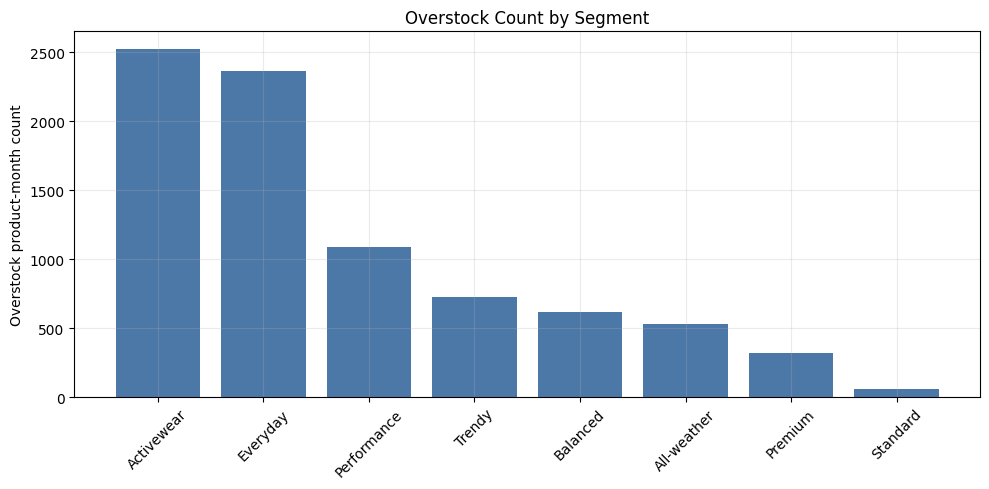

In [10]:
segment_overstock = pd.DataFrame()
if aligned_pm.empty or 'segment_final' not in aligned_pm.columns or aligned_pm['segment_final'].dropna().empty:
    print('Segment data is unavailable; segment overstock analysis is skipped.')
else:
    pm = aligned_pm.dropna(subset=['segment_final']).copy()
    segment_overstock = pm.groupby('segment_final').agg(
        total_stock_on_hand=('stock_on_hand', 'sum'),
        total_units_sold=('units_sold', 'sum'),
        average_sell_through_rate=('sell_through_rate', 'mean'),
        overstock_product_count=('overstock_flag', lambda s: int(s.fillna(False).sum())),
        overstock_rate=('overstock_flag', lambda s: s.fillna(False).mean()),
        average_days_of_supply=('days_of_supply', 'mean'),
    ).reset_index().sort_values(['overstock_product_count', 'overstock_rate'], ascending=False)
    display(segment_overstock)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(segment_overstock['segment_final'].astype(str), segment_overstock['overstock_product_count'], color='#4C78A8')
    ax.set_title('Overstock Count by Segment')
    ax.set_ylabel('Overstock product-month count')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 11. Stock on Hand vs Units Sold

Inspect product-month relationships between stock on hand and units sold, and identify high-stock slow-sales cases.

,product_id_std,year_month,category_final,segment_final,stock_on_hand,units_sold,sell_through_rate,days_of_supply,overstock_flag
54334,791,2019-03,Outdoor,Activewear,2384,2,0.0008,"36,952.0000",True
26764,2045,2022-11,Streetwear,Performance,2339,2,0.0009,"35,085.0000",True
54445,792,2019-03,Outdoor,Activewear,2334,2,0.0009,"36,177.0000",True
48029,604,2020-12,Streetwear,Everyday,2270,1,0.0004,"70,370.0000",True
44061,487,2022-05,Streetwear,Balanced,2014,1,0.0005,"62,434.0000",True
44062,487,2022-09,Streetwear,Balanced,2014,2,0.0010,"30,210.0000",True
44056,487,2021-12,Streetwear,Balanced,2011,1,0.0005,"62,341.0000",True
44057,487,2022-01,Streetwear,Balanced,2011,1,0.0005,"62,341.0000",True
43165,438,2021-10,Streetwear,Balanced,1744,1,0.0006,"54,064.0000",True
43166,438,2022-02,Streetwear,Balanced,1744,1,0.0006,"48,832.0000",True


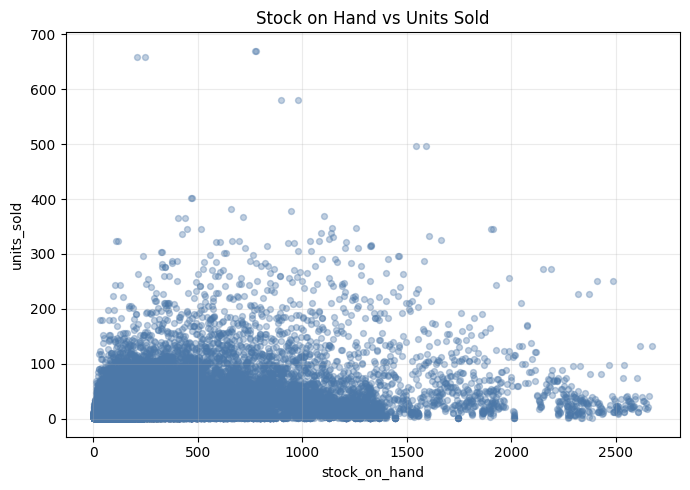

In [11]:
high_stock_slow_sales = pd.DataFrame()
if aligned_pm.empty or 'stock_on_hand' not in aligned_pm.columns or 'units_sold' not in aligned_pm.columns or aligned_pm['units_sold'].isna().all():
    print('Product-month stock and sales quantity data are insufficient for stock-vs-sales analysis.')
else:
    pm = aligned_pm.copy()
    high_stock_slow_sales = pm.sort_values(['stock_on_hand', 'units_sold'], ascending=[False, True]).copy()
    high_stock_slow_sales = high_stock_slow_sales[(high_stock_slow_sales['stock_on_hand'] >= high_stock_slow_sales['stock_on_hand'].quantile(0.90)) & (high_stock_slow_sales['units_sold'] <= high_stock_slow_sales['units_sold'].quantile(0.25))]
    display(high_stock_slow_sales[['product_id_std', 'year_month', 'category_final', 'segment_final', 'stock_on_hand', 'units_sold', 'sell_through_rate', 'days_of_supply', 'overstock_flag']].head(30))

    fig, ax = plt.subplots(figsize=(7, 5))
    sample = pm[['stock_on_hand', 'units_sold']].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(sample['stock_on_hand'], sample['units_sold'], alpha=0.35, s=18, color='#4C78A8')
    ax.set_title('Stock on Hand vs Units Sold')
    ax.set_xlabel('stock_on_hand')
    ax.set_ylabel('units_sold')
    plt.tight_layout()
    plt.show()

    if 'revenue_proxy' in pm.columns and pm['revenue_proxy'].notna().any():
        fig, ax = plt.subplots(figsize=(7, 5))
        sample = pm[['stock_on_hand', 'revenue_proxy']].replace([np.inf, -np.inf], np.nan).dropna()
        ax.scatter(sample['stock_on_hand'], sample['revenue_proxy'], alpha=0.35, s=18, color='#F58518')
        ax.set_title('Stock on Hand vs Revenue Proxy')
        ax.set_xlabel('stock_on_hand')
        ax.set_ylabel('revenue_proxy')
        plt.tight_layout()
        plt.show()

## 12. Sell-Through Rate by Category

Compare sell-through rate by category and relate it to stock levels and Revenue proxy when available.

,category_final,average_sell_through_rate,median_sell_through_rate,total_stock_on_hand,total_units_sold
2,Outdoor,0.1955,0.1000,4749891,337510
3,Streetwear,0.2405,0.1370,5759494,511467
0,Casual,0.2535,0.1538,310522,31202
1,GenZ,0.2554,0.1429,584757,48695


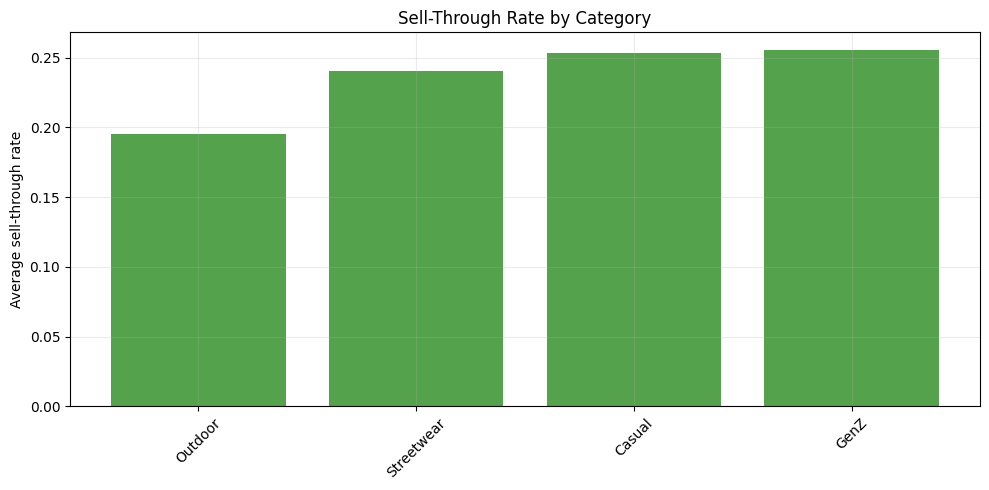

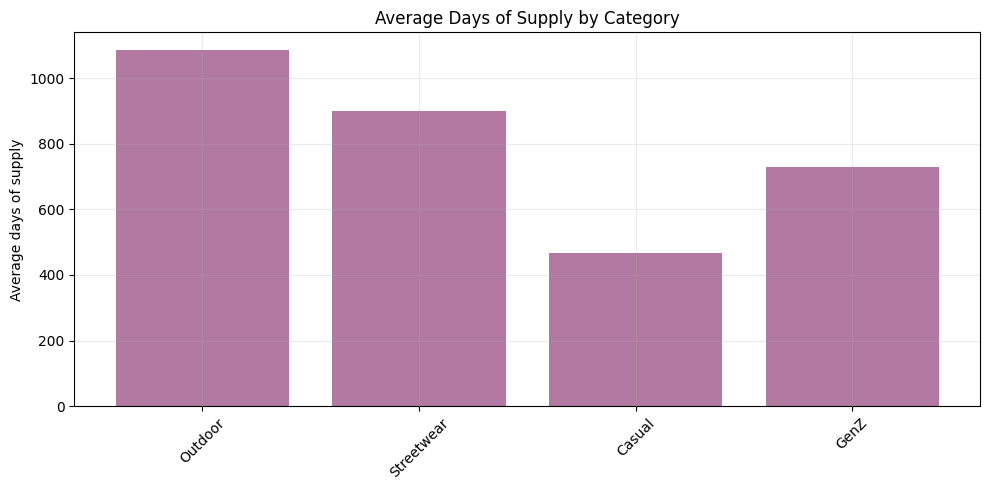

In [12]:
if category_overstock.empty or 'average_sell_through_rate' not in category_overstock.columns:
    print('Category sell-through analysis cannot be computed.')
else:
    st_plot = category_overstock.sort_values('average_sell_through_rate')
    display(st_plot[['category_final', 'average_sell_through_rate', 'median_sell_through_rate', 'total_stock_on_hand', 'total_units_sold']])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(st_plot['category_final'].astype(str), st_plot['average_sell_through_rate'], color='#54A24B')
    ax.set_title('Sell-Through Rate by Category')
    ax.set_ylabel('Average sell-through rate')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    if 'average_days_of_supply' in st_plot.columns and st_plot['average_days_of_supply'].notna().any():
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(st_plot['category_final'].astype(str), st_plot['average_days_of_supply'], color='#B279A2')
        ax.set_title('Average Days of Supply by Category')
        ax.set_ylabel('Average days of supply')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

## 13. Overstock Trend Over Time

Aggregate overstock metrics by month, inspect trend direction, and display a category-by-month overstock matrix when useful.

,year_month,overstock_count,overstock_rate,total_stock_on_hand,sell_through_rate,days_of_supply,month_start
0,2012-07,0,0.0000,23698,0.3220,96.3593,2012-07-01
1,2012-08,0,0.0000,26249,0.4807,102.7446,2012-08-01
2,2012-09,1,0.0024,27519,0.3906,144.8531,2012-09-01
3,2012-10,1,0.0023,29194,0.3383,187.3280,2012-10-01
4,2012-11,3,0.0073,30134,0.2843,228.7379,2012-11-01
...,...,...,...,...,...,...,...
121,2022-08,99,0.2148,104884,0.2068,"1,339.5009",2022-08-01
122,2022-09,111,0.2649,107309,0.1634,"1,937.0587",2022-09-01
123,2022-10,107,0.2616,104255,0.1688,"2,058.9617",2022-10-01
124,2022-11,100,0.2660,95003,0.1507,"1,923.9314",2022-11-01


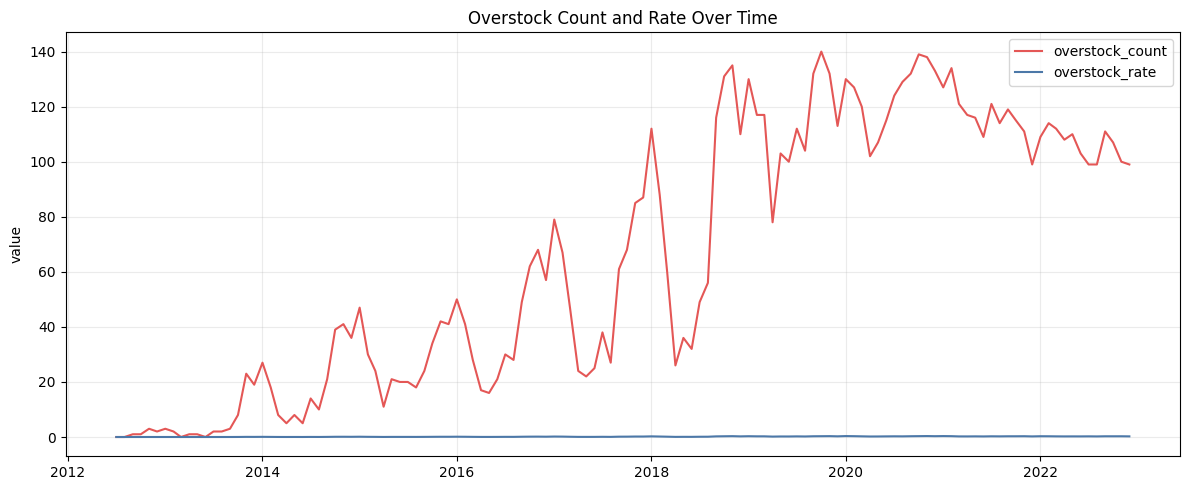

year_month,2012-07,2012-08,2012-09,2012-10,2012-11,2012-12,2013-01,2013-02,2013-03,2013-04,2013-05,2013-06,2013-07,2013-08,2013-09,2013-10,2013-11,2013-12,2014-01,2014-02,2014-03,2014-04,2014-05,2014-06,2014-07,2014-08,2014-09,2014-10,2014-11,2014-12,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12
category_final,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Casual,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0556,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0556,0.0000,0.0000,0.0588,0.0625,0.0556,0.0588,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0526,0.0952,0.0000,0.1053,0.0556,0.0000,0.0000,0.0000,0.0455,0.1111,0.0000,0.0000,0.0500,0.2222,0.0476,0.2105,0.1905,0.0500,0.0000,0.0000,0.0000,0.0000,0.0000,0.3000,0.1111,0.3200,0.3846,0.3077,0.2963,0.0690,0.0000,0.0000,0.0323,0.0968,0.1667,0.2000,0.2432,0.2857,0.2703,0.2571,0.2500,0.2500,0.1064,0.2045,0.1628,0.2045,0.1429,0.2500,0.2564,0.2703,0.2903,0.2727,0.2941,0.2143,0.1905,0.2619,0.2000,0.2051,0.2727,0.2500,0.2941,0.3438,0.3750,0.2571,0.2750,0.1667,0.1667,0.1633,0.1250,0.1707,0.1818,0.1429,0.1795,0.2000,0.1795,0.2432,0.2368,0.2000,0.2000,0.1220,0.2162,0.2000,0.1707,0.3077,0.1892,0.3143,0.2750
GenZ,0.0000,0.0000,0.0000,0.0500,0.1333,0.0000,0.1333,0.0588,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0400,0.1364,0.0833,0.1500,0.0952,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0345,0.2174,0.1481,0.1364,0.2500,0.1304,0.0741,0.0000,0.0000,0.0667,0.0323,0.0541,0.0833,0.1053,0.1613,0.0968,0.1724,0.1613,0.1515,0.0606,0.0811,0.1026,0.1111,0.0588,0.1034,0.1765,0.2069,0.1351,0.2143,0.2500,0.1176,0.0278,0.0263,0.0250,0.0500,0.0732,0.1944,0.1622,0.2593,0.2432,0.3125,0.2903,0.1316,0.0909,0.0227,0.0426,0.0909,0.0930,0.3000,0.2927,0.3939,0.3548,0.4000,0.2973,0.2979,0.2083,0.2157,0.1176,0.2000,0.1509,0.2391,0.2449,0.3000,0.2195,0.3000,0.3333,0.2609,0.2222,0.2353,0.1887,0.1754,0.1731,0.2553,0.2391,0.3023,0.2973,0.3750,0.2683,0.1786,0.1754,0.2000,0.1452,0.1552,0.1250,0.2264,0.1702,0.2326,0.2083,0.2143,0.2000,0.1667,0.1552,0.1404,0.1500,0.1579,0.1000,0.1538,0.2045,0.1905,0.1364
Outdoor,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0169,0.0000,0.0333,0.0273,0.0111,0.0108,0.0103,0.0104,0.0349,0.0206,0.0345,0.0442,0.0319,0.0311,0.0419,0.0462,0.0220,0.0110,0.0476,0.0337,0.0331,0.0213,0.0481,0.0426,0.0260,0.0341,0.0505,0.0543,0.0681,0.0372,0.0543,0.0517,0.0791,0.0510,0.0703,0.0601,0.0350,0.0146,0.0677,0.0778,0.0576,0.0215,0.0104,0.0316,0.0833,0.0388,0.0990,0.0979,0.0887,0.0508,0.1809,0.1421,0.1477,0.0573,0.1053,0.1130,0.1963,0.1647,0.2938,0.3121,0.2933,0.1323,0.2775,0.2356,0.2847,0.1553,0.2485,0.2339,0.2895,0.2500,0.3399,0.3221,0.3185,0.1627,0.3465,0.3143,0.2937,0.2096,0.2439,0.3176,0.3824,0.3106,0.3310,0.3759,0.3889,0.2270,0.3333,0.3459,0.2556,0.2901,0.3721,0.3309,0.4103,0.3488,0.3471,0.3566,0.3419,0.2051,0.3839,0.3411,0.2963,0.3077,0.3617,0.3571,0.4167,0.3556,0.4000,0.3871,0.3667,0.2569
Streetwear,0.0000,0.0000,0.0044,0.0000,0.0047,0.0090,0.0046,0.0045,0.0000,0.0039,0.0039,0.0000,0.0078,0.0076,0.0112,0.0233,0.0700,0.0664,0.0796,0.0449,0.0233,0.0108,0.0226,0.

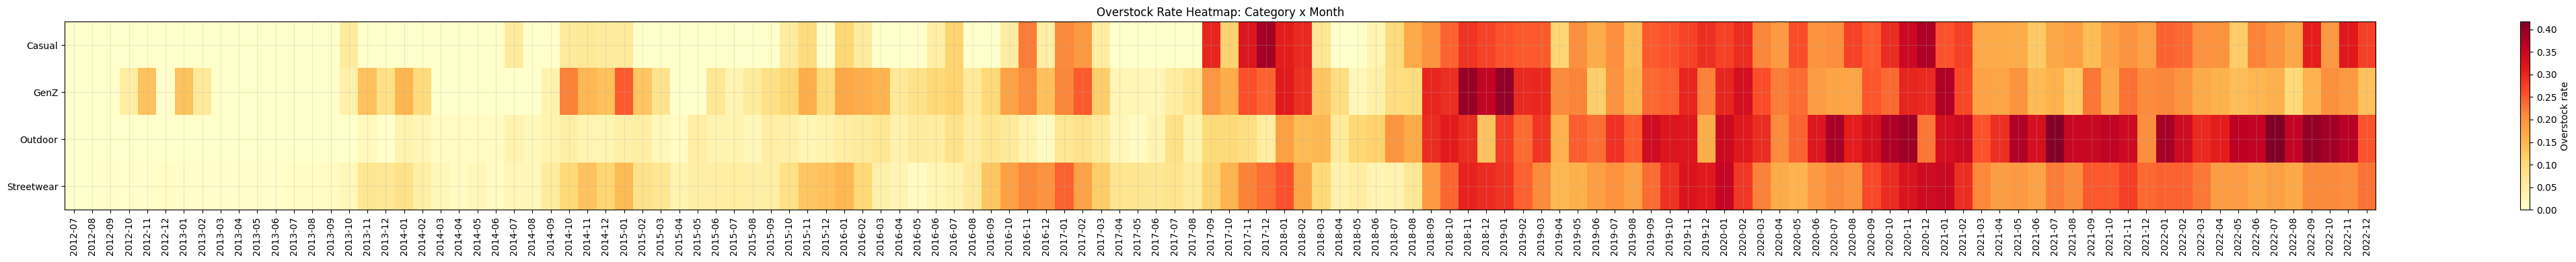

In [13]:
monthly_overstock = pd.DataFrame()
heatmap_matrix = pd.DataFrame()

if aligned_pm.empty:
    print('Aligned product-month data is unavailable; overstock trend analysis cannot be computed.')
else:
    pm = aligned_pm.copy()
    monthly_overstock = pm.groupby('year_month').agg(
        overstock_count=('overstock_flag', lambda s: int(s.fillna(False).sum())),
        overstock_rate=('overstock_flag', lambda s: s.fillna(False).mean()),
        total_stock_on_hand=('stock_on_hand', 'sum'),
        sell_through_rate=('sell_through_rate', 'mean'),
        days_of_supply=('days_of_supply', 'mean'),
    ).reset_index()
    monthly_overstock['month_start'] = pd.PeriodIndex(monthly_overstock['year_month'], freq='M').to_timestamp()
    display(monthly_overstock)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_overstock['month_start'], monthly_overstock['overstock_count'], label='overstock_count', color='#E45756')
    ax.plot(monthly_overstock['month_start'], monthly_overstock['overstock_rate'], label='overstock_rate', color='#4C78A8')
    ax.set_title('Overstock Count and Rate Over Time')
    ax.set_ylabel('value')
    ax.legend()
    plt.tight_layout()
    plt.show()

    if 'category_final' in pm.columns:
        top_categories = category_overstock.head(8)['category_final'].tolist() if not category_overstock.empty else pm['category_final'].value_counts().head(8).index.tolist()
        heatmap_matrix = pm[pm['category_final'].isin(top_categories)].pivot_table(index='category_final', columns='year_month', values='overstock_flag', aggfunc=lambda s: pd.Series(s).fillna(False).mean()).fillna(0)
        display(heatmap_matrix)
        fig, ax = plt.subplots(figsize=(max(10, heatmap_matrix.shape[1] * 0.35), max(4, heatmap_matrix.shape[0] * 0.45)))
        im = ax.imshow(heatmap_matrix.values, aspect='auto', cmap='YlOrRd')
        ax.set_title('Overstock Rate Heatmap: Category x Month')
        ax.set_xticks(np.arange(heatmap_matrix.shape[1]))
        ax.set_xticklabels(heatmap_matrix.columns, rotation=90)
        ax.set_yticks(np.arange(heatmap_matrix.shape[0]))
        ax.set_yticklabels(heatmap_matrix.index)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Overstock rate')
        plt.tight_layout()
        plt.show()

## 14. Leakage-Safe Overstock Forecast Feature Preview

Shift monthly overstock and sell-through metrics by one month before merging them into daily Revenue rows. A daily row in month `M` receives the previous month's realized inventory signal unless current/future inventory plans are genuinely known in advance.

In [14]:
daily_with_overstock = pd.DataFrame()
feature_registry = pd.DataFrame()

if monthly_overstock.empty:
    print('Monthly overstock metrics are unavailable; forecast feature preview cannot be built.')
else:
    monthly_features = monthly_overstock.sort_values('month_start').copy()
    monthly_features['overstock_count_lag'] = monthly_features['overstock_count'].shift(1)
    monthly_features['overstock_rate_lag'] = monthly_features['overstock_rate'].shift(1)
    monthly_features['sell_through_rate_lag'] = monthly_features['sell_through_rate'].shift(1)
    monthly_features['days_of_supply_lag'] = monthly_features['days_of_supply'].shift(1)
    monthly_features['overstock_rate_roll_mean_3m'] = monthly_features['overstock_rate'].shift(1).rolling(3, min_periods=2).mean()
    monthly_features['sell_through_rate_roll_mean_3m'] = monthly_features['sell_through_rate'].shift(1).rolling(3, min_periods=2).mean()
    if not heatmap_matrix.empty:
        cat_pressure = aligned_pm.groupby(['year_month', 'category_final'])['overstock_flag'].mean().reset_index(name='category_overstock_rate')
        top_cat_pressure = cat_pressure.groupby('year_month')['category_overstock_rate'].max().reset_index(name='category_overstock_pressure')
        monthly_features = monthly_features.merge(top_cat_pressure, on='year_month', how='left')
        monthly_features['category_overstock_pressure_lag'] = monthly_features['category_overstock_pressure'].shift(1)

    if revenue_daily.empty:
        daily_with_overstock = monthly_features.copy()
    else:
        daily_with_overstock = revenue_daily.merge(
            monthly_features[['year_month', 'overstock_count_lag', 'overstock_rate_lag', 'sell_through_rate_lag', 'days_of_supply_lag', 'overstock_rate_roll_mean_3m', 'sell_through_rate_roll_mean_3m'] + ([c for c in ['category_overstock_pressure_lag'] if c in monthly_features.columns])],
            on='year_month',
            how='left'
        )
    preview_cols = ['date', 'revenue', 'year_month', 'overstock_count_lag', 'overstock_rate_lag', 'sell_through_rate_lag', 'days_of_supply_lag', 'overstock_rate_roll_mean_3m', 'sell_through_rate_roll_mean_3m']
    for c in ['category_overstock_pressure_lag']:
        if c in daily_with_overstock.columns:
            preview_cols.append(c)
    preview_cols = [c for c in preview_cols if c in daily_with_overstock.columns]
    display(daily_with_overstock[preview_cols].head(40))

    current_month_known_only = ['overstock_count', 'overstock_rate', 'sell_through_rate', 'days_of_supply']
    historical_safe = [c for c in daily_with_overstock.columns if c.endswith('_lag') or c.endswith('_3m')]
    feature_registry = pd.DataFrame({
        'feature': current_month_known_only + historical_safe,
        'feature_type': ['requires known current/future inventory state'] * len(current_month_known_only) + ['historical lagged monthly only'] * len(historical_safe),
        'forecast_use_note': ['Use only if current/future inventory plans or known stock status are genuinely available before prediction.'] * len(current_month_known_only) + ['Leakage-safe because the metric is shifted to prior month history before forecast use.'] * len(historical_safe),
    })
    display(feature_registry)

,date,revenue,year_month,overstock_count_lag,overstock_rate_lag,sell_through_rate_lag,days_of_supply_lag,overstock_rate_roll_mean_3m,sell_through_rate_roll_mean_3m,category_overstock_pressure_lag
0,2012-07-04,"5,123,547.9400",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,feature,feature_type,forecast_use_note
0,overstock_count,requires known current/future inventory state,Use only if current/future inventory plans or ...
1,overstock_rate,requires known current/future inventory state,Use only if current/future inventory plans or ...
2,sell_through_rate,requires known current/future inventory state,Use only if current/future inventory plans or ...
3,days_of_supply,requires known current/future inventory state,Use only if current/future inventory plans or ...
4,overstock_count_lag,historical lagged monthly only,Leakage-safe because the metric is shifted to ...
5,overstock_rate_lag,historical lagged monthly only,Leakage-safe because the metric is shifted to ...
6,sell_through_rate_lag,historical lagged monthly only,Leakage-safe because the metric is shifted to ...
7,days_of_supply_lag,historical lagged monthly only,Leakage-safe because the metric is shifted to ...
8,overstock_rate_roll_mean_3m,historical lagged monthly only,Leakage-safe because the metric is shifted to ...
9,sell_through_rate_roll_mean_3m,historical lagged monthly only,Leakage-safe because the metric is shifted to ...


## 15. Key Observations and Warnings

Final concise summary with overstock concentration, weak sell-through groups, replenishment review candidates, data quality notes, and leakage-safe features.

In [15]:
def fmt(x, digits=4):
    return 'n/a' if pd.isna(x) else f'{x:,.{digits}f}'

summary_lines = []

if not category_overstock.empty:
    top_count = category_overstock.sort_values('overstock_product_count', ascending=False).head(5)
    top_rate = category_overstock.sort_values('overstock_rate', ascending=False).head(5)
    summary_lines.append('Categories with highest overstock count: ' + ', '.join(f"{r.category_final} ({int(r.overstock_product_count)})" for r in top_count.itertuples()))
    summary_lines.append('Categories with highest overstock rate: ' + ', '.join(f"{r.category_final} ({r.overstock_rate:.2%})" for r in top_rate.itertuples()))
    weak_st = category_overstock.sort_values('average_sell_through_rate').head(5)
    summary_lines.append('Categories with weakest sell-through rate: ' + ', '.join(f"{r.category_final} ({r.average_sell_through_rate:.3f})" for r in weak_st.itertuples()))
else:
    summary_lines.append('Category-level overstock analysis could not be computed because category data was unavailable.')

if not segment_overstock.empty:
    top_seg = segment_overstock.sort_values(['overstock_product_count', 'overstock_rate'], ascending=False).head(5)
    summary_lines.append('Segments with highest overstock risk: ' + ', '.join(f"{r.segment_final} ({r.overstock_rate:.2%})" for r in top_seg.itertuples()))
else:
    summary_lines.append('Segment-level overstock analysis was skipped because segment data was unavailable.')

if not high_stock_slow_sales.empty:
    top_products = high_stock_slow_sales.head(8)
    summary_lines.append('Products/groups with high stock on hand but slow sales: ' + ', '.join(f"{r.product_id_std} {r.category_final} {r.year_month}" for r in top_products.itertuples()))

if not category_overstock.empty:
    top_share = category_overstock['overstock_product_count'].head(3).sum() / category_overstock['overstock_product_count'].sum() if category_overstock['overstock_product_count'].sum() else np.nan
    concentration = 'concentrated' if pd.notna(top_share) and top_share >= 0.6 else 'broad-based'
    summary_lines.append(f'Overstock appears {concentration} across groups under the current category concentration view.')

if not category_overstock.empty:
    review_candidates = category_overstock[(category_overstock['overstock_rate'] >= category_overstock['overstock_rate'].quantile(0.75)) | (category_overstock['average_sell_through_rate'] <= category_overstock['average_sell_through_rate'].quantile(0.25))].head(5)
    if not review_candidates.empty:
        summary_lines.append('Groups that may need reduced replenishment or inventory review: ' + ', '.join(review_candidates['category_final'].astype(str).tolist()))

warnings_all = []
warnings_all.extend(inventory_warnings)
warnings_all.extend(sales_qty_warnings)
if warnings_all:
    summary_lines.append('Inventory and sales quantity data quality warnings: ' + '; '.join(warnings_all))
else:
    summary_lines.append('Inventory and sales quantity data quality warnings: none beyond the checks reported in the notebook tables.')

summary_lines.append('Recommended leakage-safe overstock forecast features: overstock_count_lag, overstock_rate_lag, sell_through_rate_lag, days_of_supply_lag, overstock_rate_roll_mean_3m, sell_through_rate_roll_mean_3m, and category_overstock_pressure_lag.')
summary_lines.append('Future inventory, overstock, or sell-through values must not be used directly unless known before prediction. Otherwise use only historical lagged inventory signals.')
summary_lines.append('Causal caution: this is observational EDA. Overstock and slow sales can move together because of assortment changes, seasonality, pricing, promotions, and replenishment timing.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Categories with highest overstock count: Streetwear (4125), Outdoor (2845), GenZ (728), Casual (533)
- Categories with highest overstock rate: GenZ (15.58%), Casual (15.22%), Outdoor (13.52%), Streetwear (13.30%)
- Categories with weakest sell-through rate: Outdoor (0.196), Streetwear (0.240), Casual (0.253), GenZ (0.255)
- Segments with highest overstock risk: Activewear (13.80%), Everyday (17.40%), Performance (14.18%), Trendy (15.58%), Balanced (9.27%)
- Products/groups with high stock on hand but slow sales: 791 Outdoor 2019-03, 2045 Streetwear 2022-11, 792 Outdoor 2019-03, 604 Streetwear 2020-12, 487 Streetwear 2022-05, 487 Streetwear 2022-09, 487 Streetwear 2021-12, 487 Streetwear 2022-01
- Overstock appears concentrated across groups under the current category concentration view.
- Groups that may need reduced replenishment or inventory review: Outdoor, GenZ
- Inventory and sales quantity data quality warnings: none beyond the checks reported in t